Import libraries

In [22]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

Load Processed Datasets

In [23]:
X_train = pd.read_csv('X_train_processed.csv')
X_test = pd.read_csv('X_test_processed.csv')
y_train = pd.read_csv('y_train.csv')
y_test = pd.read_csv('y_test.csv')

Function to bin risk scores into categories

In [24]:
def bin_risk_score(score):
    if score <= 19:
        return 0  # Very Low
    elif score <= 39:
        return 1  # Low
    elif score <= 59:
        return 2  # Medium
    elif score <= 79:
        return 3  # High
    else:
        return 4  # Very High

Apply binning

In [25]:
y_train_binned = y_train['risk_score'].apply(bin_risk_score)
y_test_binned = y_test['risk_score'].apply(bin_risk_score)


Fit Logistic Regression (multinomial)

In [26]:
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train_binned)

c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

Predict on test set

In [27]:
y_pred = log_reg.predict(X_test)

Evaluate the model using accuracy score, classification report (precision, recall, f1-score), and confusion matrix heatmap to visualizate misclassifications

In [28]:
print("Accuracy Score:", accuracy_score(y_test_binned, y_pred))
print("\nClassification Report:\n", classification_report(y_test_binned, y_pred))

Accuracy Score: 0.9047619047619048

Classification Report:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00         0
           2       0.00      0.00      0.00         1
           3       0.00      0.00      0.00         1
           4       0.97      0.95      0.96        40

    accuracy                           0.90        42
   macro avg       0.24      0.24      0.24        42
weighted avg       0.93      0.90      0.92        42



c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMet

Confusion Matrix

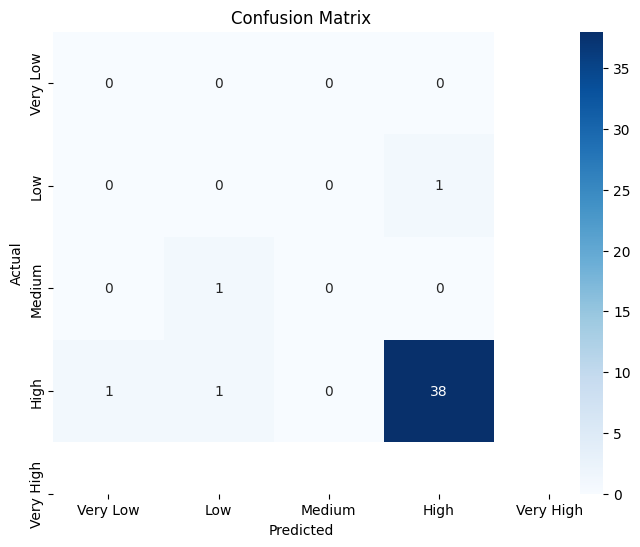

Train: risk_score
4    0.898204
1    0.035928
2    0.035928
0    0.017964
3    0.011976
Name: proportion, dtype: float64
Test: risk_score
4    0.952381
2    0.023810
3    0.023810
Name: proportion, dtype: float64


In [29]:
cm = confusion_matrix(y_test_binned, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
            yticklabels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

print("Train:", y_train_binned.value_counts(normalize=True))
print("Test:", y_test_binned.value_counts(normalize=True))
